In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glass.xlsx to glass.xlsx


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.utils import resample

In [ ]:
df = pd.read_excel("glass.xlsx")

df.head()

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [ ]:
df = pd.read_excel(
    "glass.xlsx",
    sheet_name='glass',
    skiprows=1 # Adjust skiprows if necessary, based on the actual sheet structure
)
df.head()

['Description', 'glass']


The code below loads the data from the 'glass' sheet of the 'glass.xlsx' file, skipping the first row (assuming it's a header or description). This code was previously introduced in cell `W8YB_Dn0Fdjh`.

In [ ]:
df = pd.read_excel(
    "glass.xlsx",
    sheet_name='glass',
    skiprows=1 # Adjust skiprows if necessary, based on the actual sheet structure
)
df.head()

,1.52101,13.64,4.49,1.1,71.78,0.06,8.75,0,0.1,1
0,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00,1
1,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00,1
2,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00,1
3,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00,1
4,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   1.52101  213 non-null    float64
 1   13.64    213 non-null    float64
 2   4.49     213 non-null    float64
 3   1.1      213 non-null    float64
 4   71.78    213 non-null    float64
 5   0.06     213 non-null    float64
 6   8.75     213 non-null    float64
 7   0        213 non-null    float64
 8   0.1      213 non-null    float64
 9   1        213 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [ ]:
df.describe()

,1.52101,13.64,4.49,1.1,71.78,0.06,8.75,0,0.1,1
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518353,13.406761,2.676056,1.446526,72.655023,0.499108,8.957934,0.175869,0.057277,2.788732
std,0.003039,0.818371,1.440453,0.499882,0.774052,0.653035,1.426435,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.830000,3.600000,1.630000,73.090000,0.610000,9.180000,0.000000,0.100000,3.000000
max,1.533930,17.380000,3.980000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
print(df.dtypes)

1.52101    float64
13.64      float64
4.49       float64
1.1        float64
71.78      float64
0.06       float64
8.75       float64
0          float64
0.1        float64
1            int64
dtype: object


In [ ]:
df.isnull().sum()

,0
1.52101,0
13.64,0
4.49,0
1.1,0
71.78,0
0.06,0
8.75,0
0,0
0.1,0
1,0


In [ ]:
print(df.columns)

Index([1.52101, 13.64, 4.49, 1.1, 71.78, 0.06, 8.75, 0, '0.1', 1], dtype='object')


## Exploratory Data Analysis

EDA helps understand the structure of the dataset,
identify missing values, outliers, and feature distributions.

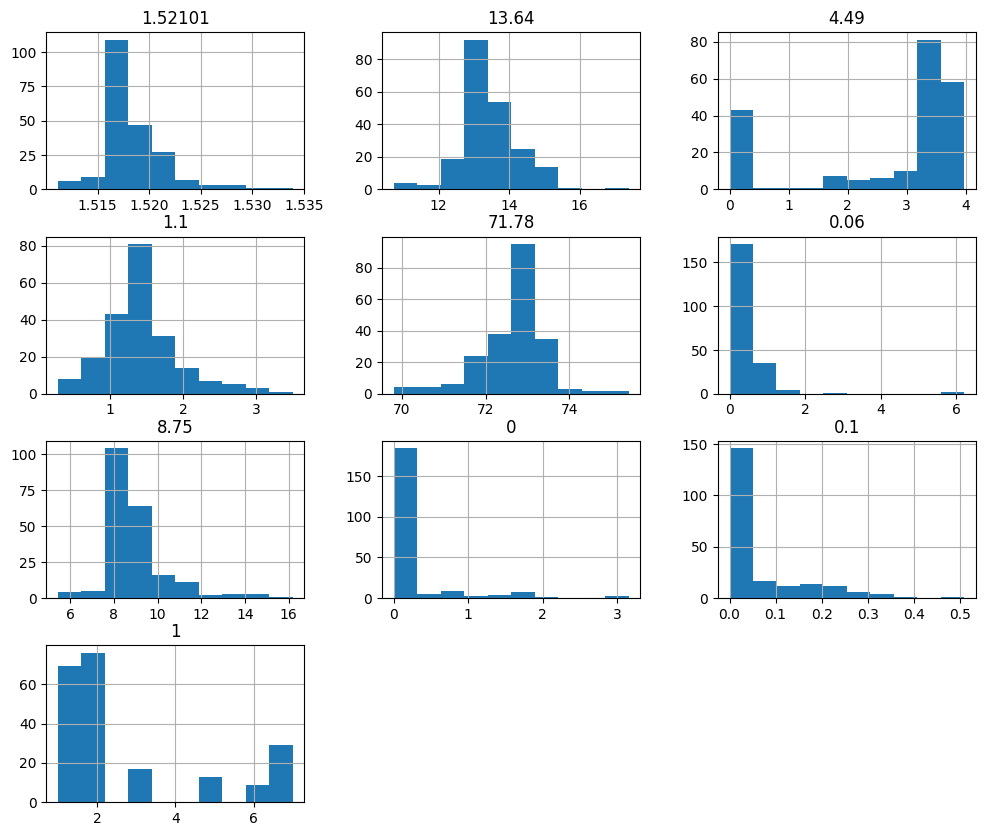

In [ ]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.hist(figsize=(12,10))

plt.show()

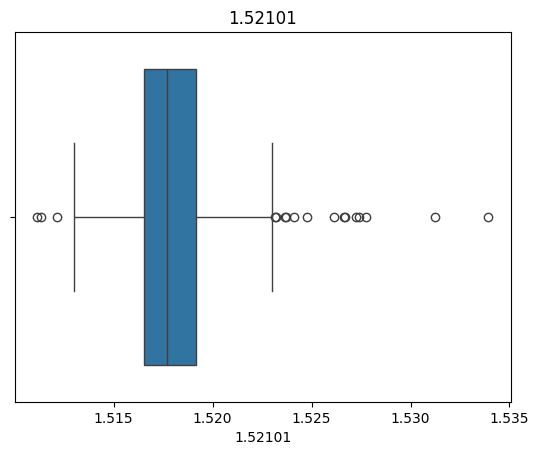

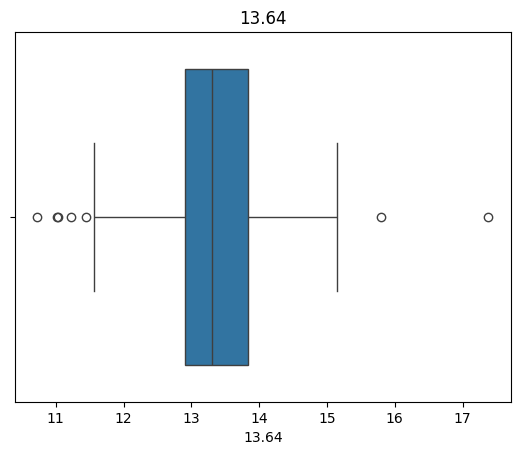

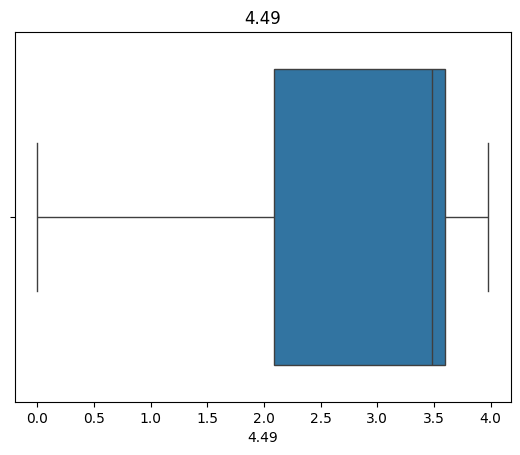

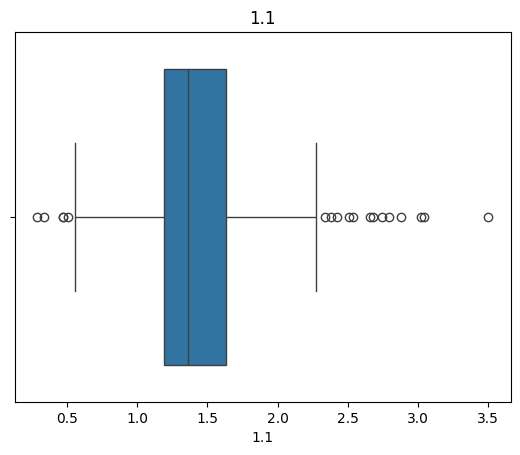

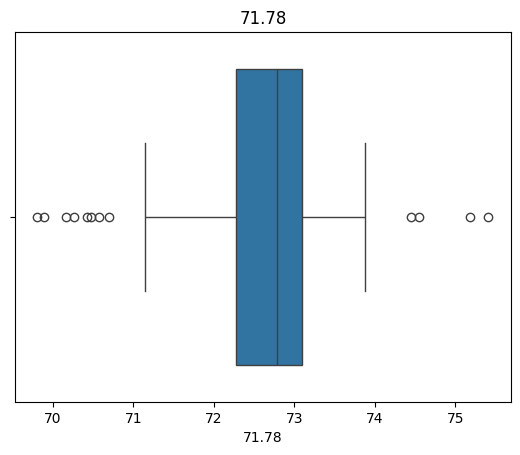

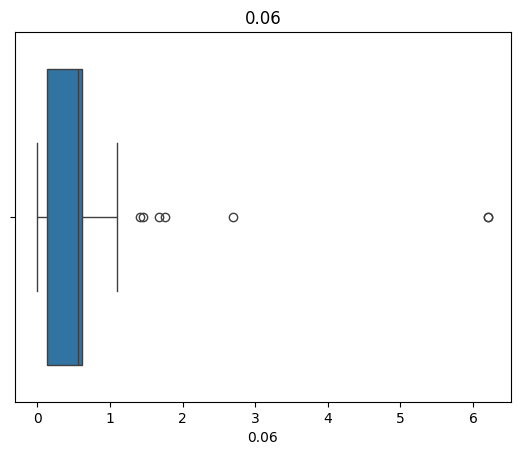

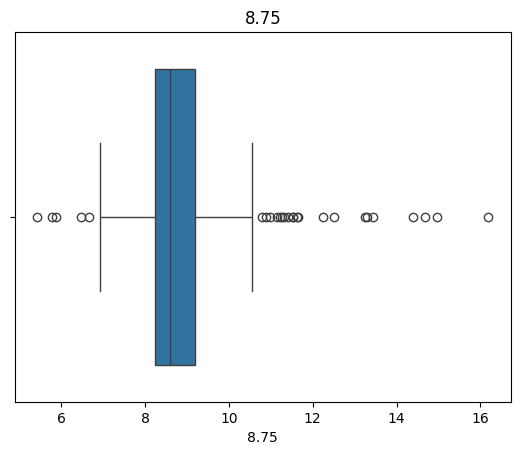

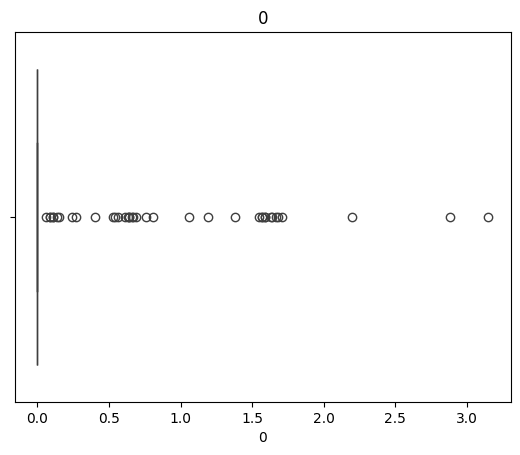

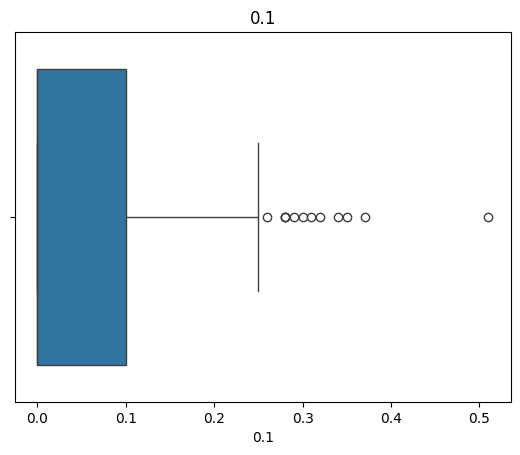

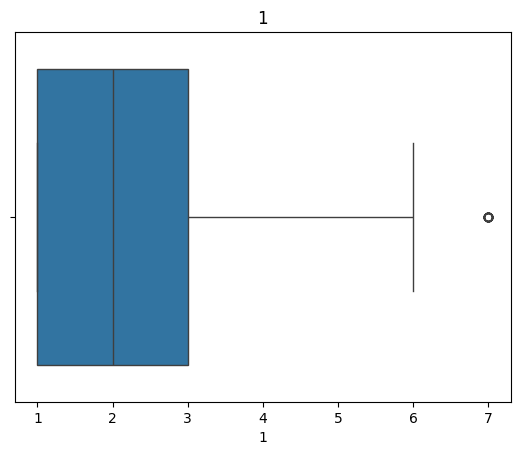

In [ ]:
import seaborn as sns

for col in numeric_df.columns:

    plt.figure()

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

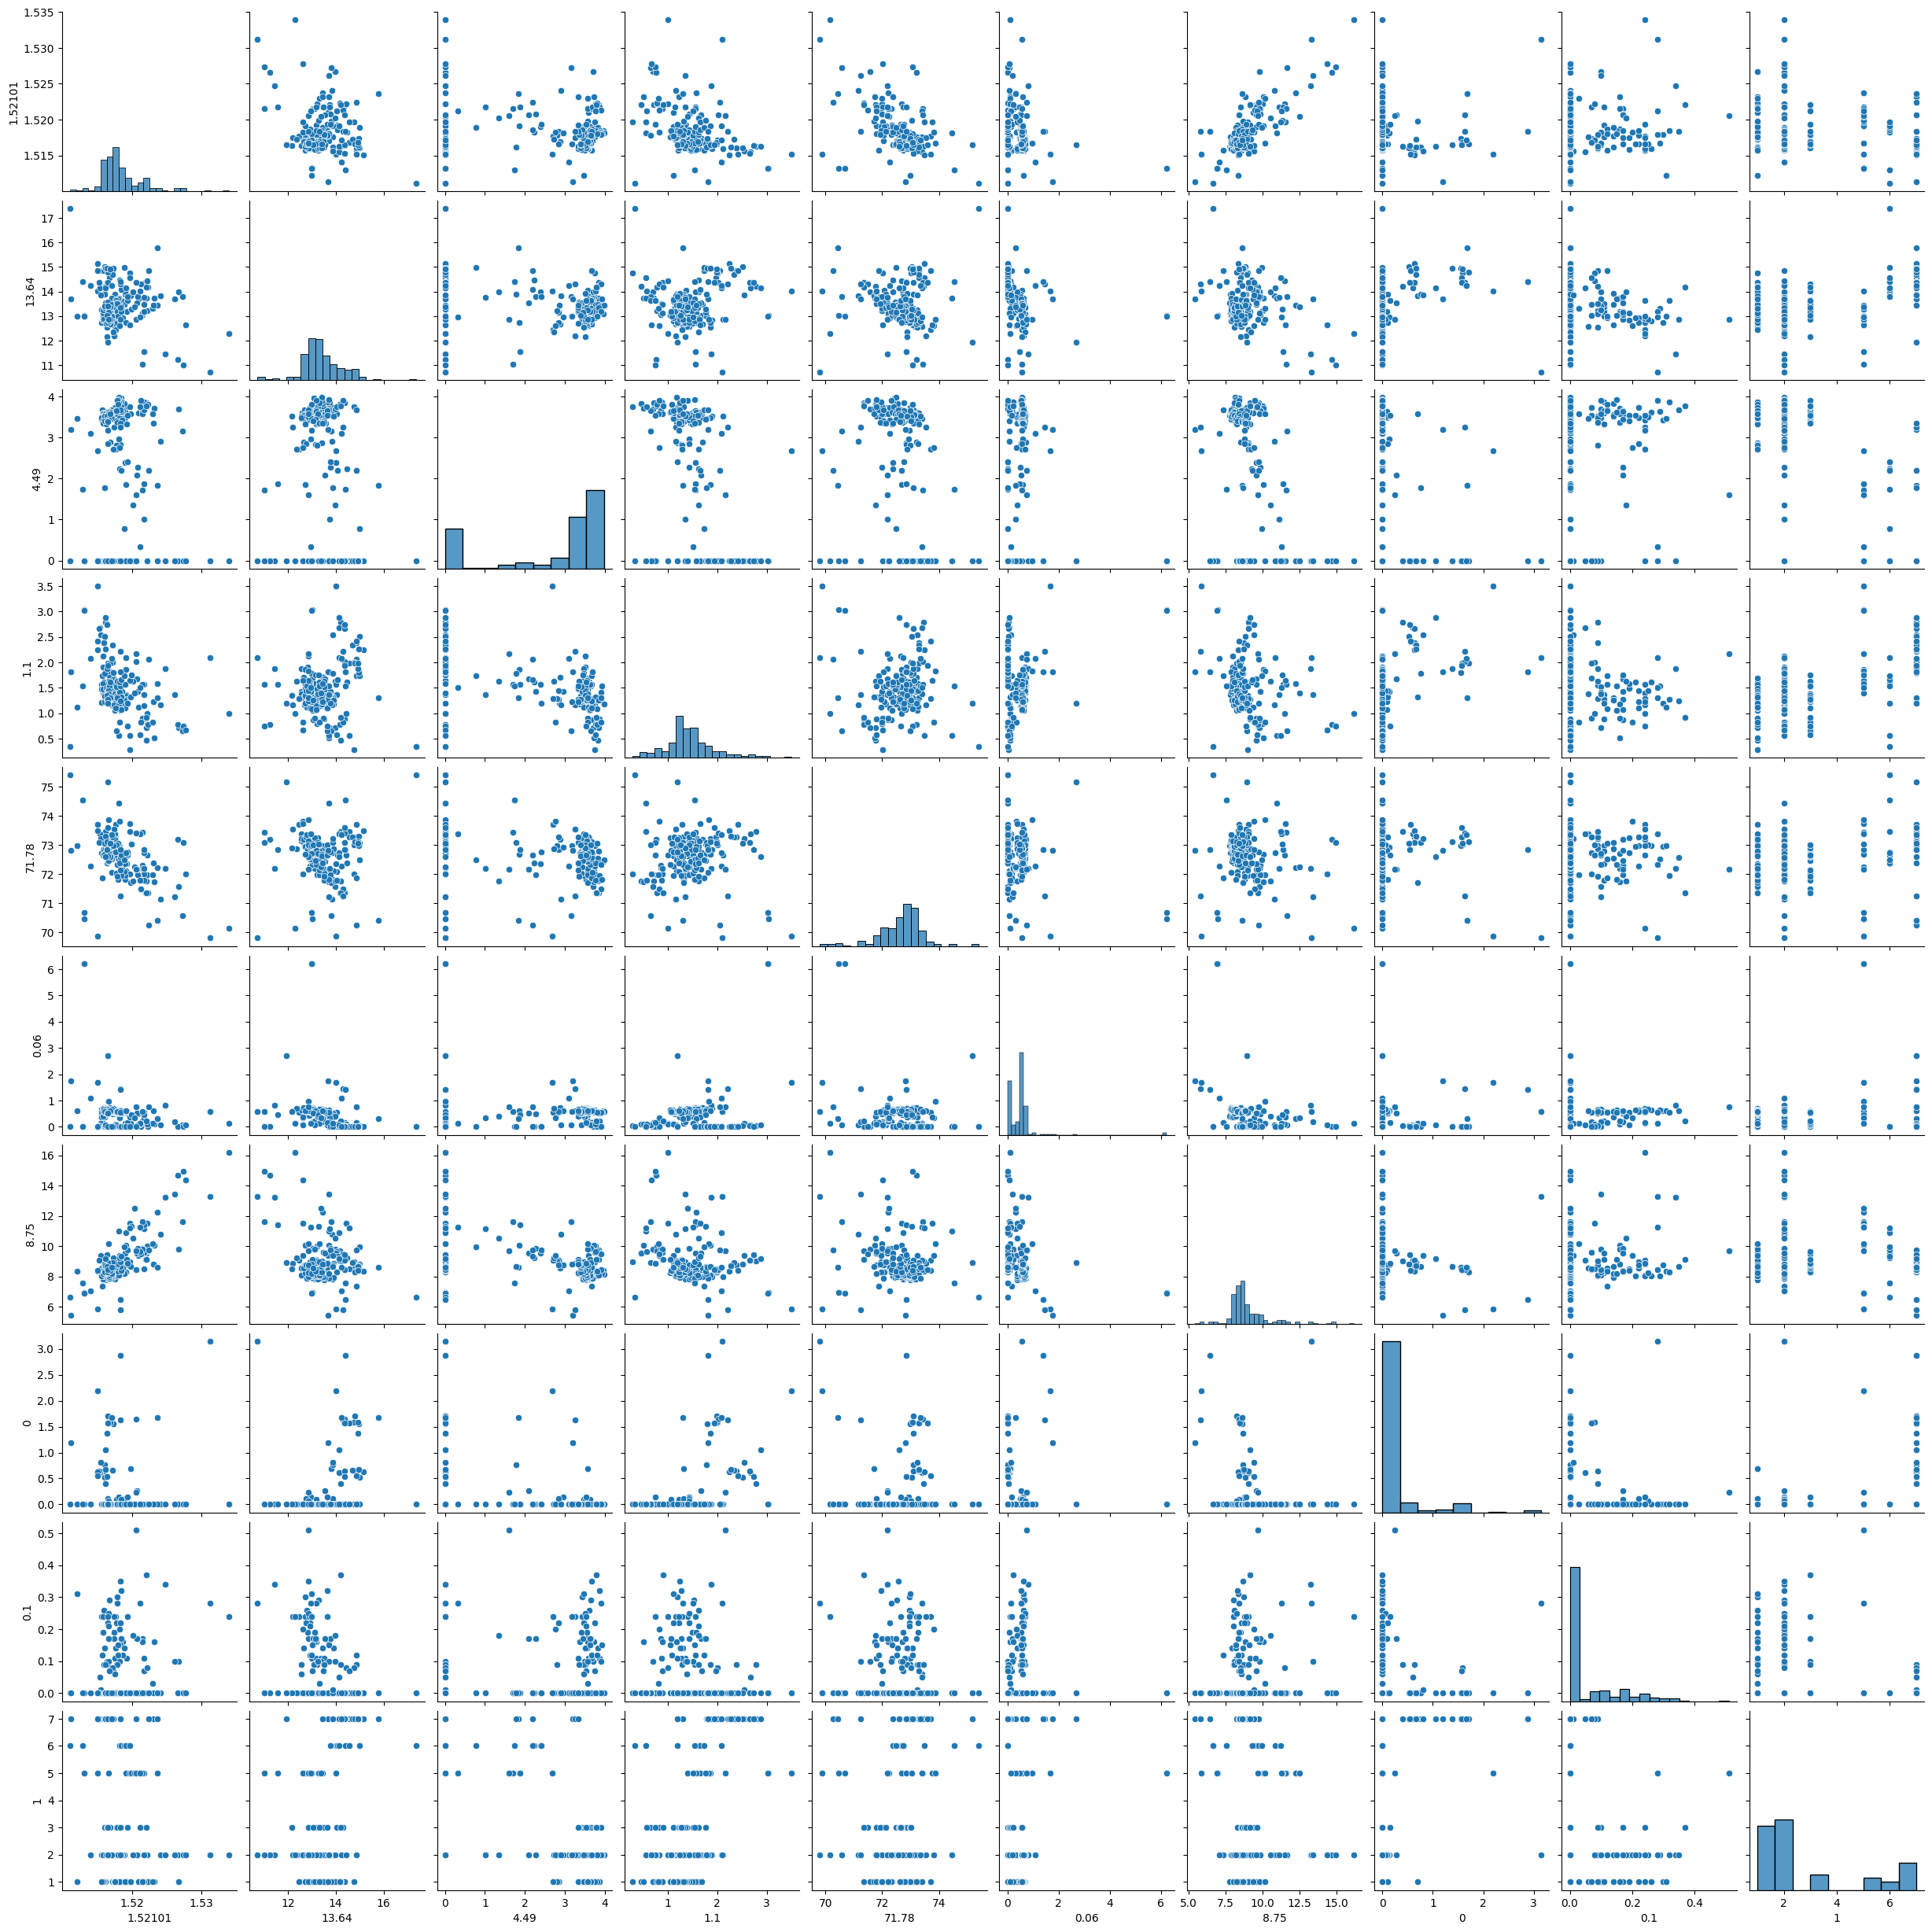

In [ ]:
sns.pairplot(df)

plt.show()

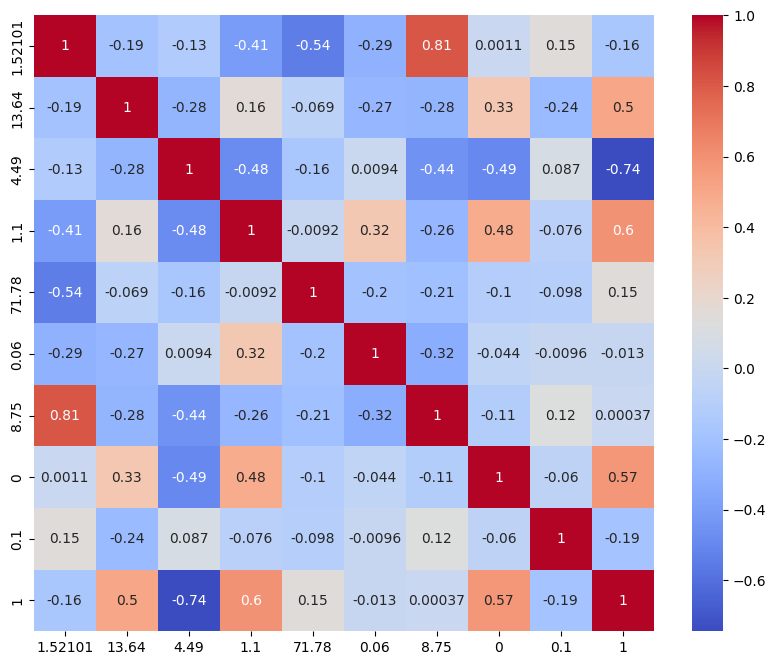

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Data Visualization

Histograms, boxplots, pairplots, and heatmaps
help visualize distributions, outliers,
and feature relationships.

In [ ]:
df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

In [ ]:
print(df.dtypes)

1.52101    float64
13.64      float64
4.49       float64
1.1        float64
71.78      float64
0.06       float64
8.75       float64
0          float64
0.1        float64
1            int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

In [ ]:
print(df.columns)

Index([1.52101, 13.64, 4.49, 1.1, 71.78, 0.06, 8.75, 0, '0.1', 1], dtype='object')


In [ ]:
# Define the correct column names
columns_names = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

# Assign the new column names to the DataFrame
df.columns = columns_names

X = df.drop('Type', axis=1)
y = df['Type']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.2,

    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.7441860465116279


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.63      0.80      0.71        15
           3       1.00      0.67      0.80         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.78      0.88         9

    accuracy                           0.74        43
   macro avg       0.81      0.67      0.72        43
weighted avg       0.77      0.74      0.75        43



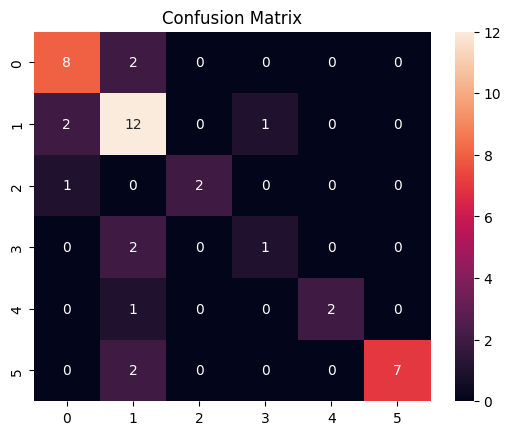

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

print(
    "Bagging Accuracy:",
    accuracy_score(y_test, bagging_pred)
)

Bagging Accuracy: 0.7441860465116279


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

boosting_model = AdaBoostClassifier(
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

print(
    "Boosting Accuracy:",
    accuracy_score(y_test, boosting_pred)
)

Boosting Accuracy: 0.6046511627906976


In [ ]:
print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Bagging Accuracy:",
    accuracy_score(y_test, bagging_pred)
)

print(
    "Boosting Accuracy:",
    accuracy_score(y_test, boosting_pred)
)

Random Forest Accuracy: 0.7441860465116279
Bagging Accuracy: 0.7441860465116279
Boosting Accuracy: 0.6046511627906976


## Conclusion

Random Forest, Bagging, and Boosting models
were implemented on the Glass dataset.

EDA, preprocessing, feature scaling,
and model evaluation were successfully performed.

The models were compared using accuracy,
precision, recall, and F1-score metrics.

# Additional Notes

## 1. Bagging and Boosting Methods

### Bagging
Bagging (Bootstrap Aggregating) is an ensemble learning technique where multiple models are trained independently using random subsets of the dataset.

Example:
- Random Forest

Advantages:
- Reduces overfitting
- Improves model stability
- Reduces variance



### Boosting
Boosting is an ensemble technique where models are trained sequentially. Each new model focuses on correcting the errors made by previous models.

Example:
- AdaBoost

Advantages:
- Improves prediction accuracy
- Reduces bias
- Learns from mistakes
